First 5 rows:
   light      ax      ay      az      gx      gy      gz        label
0   2328  0.0219 -0.0079  1.0065 -0.2441  0.1221 -0.1221  brightshaky
1   2327  0.0222 -0.0083  1.0070 -0.2441  0.0610 -0.1831  brightshaky
2   2326  0.0216 -0.0083  1.0072 -0.3052  0.1831 -0.1831  brightshaky
3   2325  0.0226 -0.0083  1.0073 -0.3052  0.2441 -0.0610  brightshaky
4   2325  0.0219 -0.0079  1.0067 -0.2441  0.2441 -0.0610  brightshaky

Class counts:
label
brightshaky       267
lowlightshaky     265
brightstable      259
lowlightstable    257
Name: count, dtype: int64

Label mapping:
brightshaky -> 0
brightstable -> 1
lowlightshaky -> 2
lowlightstable -> 3
Epoch 10/100, Loss: 1.4007
Epoch 20/100, Loss: 1.3502
Epoch 30/100, Loss: 1.3020
Epoch 40/100, Loss: 1.2462
Epoch 50/100, Loss: 1.1801
Epoch 60/100, Loss: 1.1022
Epoch 70/100, Loss: 1.0150
Epoch 80/100, Loss: 0.9204
Epoch 90/100, Loss: 0.8189
Epoch 100/100, Loss: 0.7101

Test Accuracy: 0.9810

Confusion Matrix:
[[51  3  0  0]
 [ 0 52  0  0

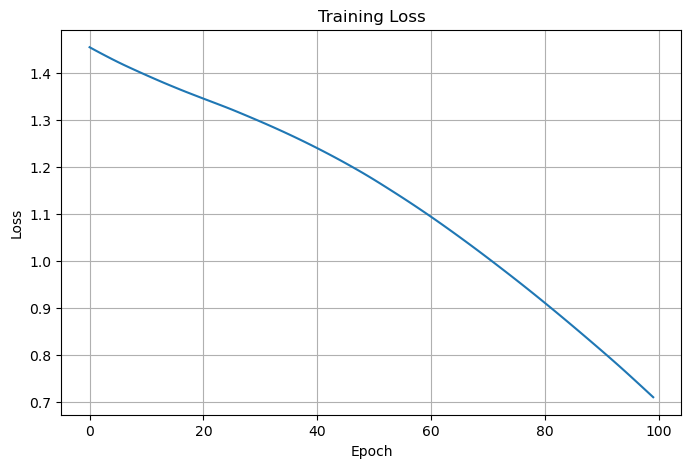

W0413 20:07:08.873000 2280 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features



Saved PyTorch weights to photo_assistant_model.pth


W0413 20:07:09.148000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0413 20:07:09.148000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0413 20:07:09.148000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `PhotoAssistantNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PhotoAssistantNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/anaconda3/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_convert

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported ONNX model to photo_assistant_model.onnx
Saved scaler/labels to photo_assistant_metadata.json


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nClass counts:")
print(df["label"].value_counts())

X = df[["light", "ax", "ay", "az", "gx", "gy", "gz"]].copy()
y = df["label"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ----------------------------
# 2. Define model
# ----------------------------
class PhotoAssistantNet(nn.Module):
    def __init__(self, input_size=7, num_classes=4):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = PhotoAssistantNet(input_size=7, num_classes=len(label_encoder.classes_))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 3. Train
# ----------------------------
epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = loss_fn(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ----------------------------
# 4. Evaluate
# ----------------------------
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    predictions = torch.argmax(test_outputs, dim=1)

accuracy = accuracy_score(y_test_t.numpy(), predictions.numpy())
cm = confusion_matrix(y_test_t.numpy(), predictions.numpy())

print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test_t.numpy(),
    predictions.numpy(),
    target_names=label_encoder.classes_,
    zero_division=0
))

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ----------------------------
# 5. Save PyTorch model
# ----------------------------
torch.save(model.state_dict(), "photo_assistant_model.pth")
print("\nSaved PyTorch weights to photo_assistant_model.pth")

# ----------------------------
# 6. Export ONNX
# ----------------------------
dummy_input = torch.randn(1, 7, dtype=torch.float32)
torch.onnx.export(
    model,
    dummy_input,
    "photo_assistant_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)
print("Exported ONNX model to photo_assistant_model.onnx")

# ----------------------------
# 7. Save scaler + labels
# ----------------------------
metadata = {
    "feature_order": ["light", "ax", "ay", "az", "gx", "gy", "gz"],
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "labels": label_encoder.classes_.tolist()
}

with open("photo_assistant_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved scaler/labels to photo_assistant_metadata.json")

In [2]:
pip install onnx onnxscript --user

Note: you may need to restart the kernel to use updated packages.


First 5 rows:
   light      ax      ay      az      gx      gy      gz        label
0   2328  0.0219 -0.0079  1.0065 -0.2441  0.1221 -0.1221  brightshaky
1   2327  0.0222 -0.0083  1.0070 -0.2441  0.0610 -0.1831  brightshaky
2   2326  0.0216 -0.0083  1.0072 -0.3052  0.1831 -0.1831  brightshaky
3   2325  0.0226 -0.0083  1.0073 -0.3052  0.2441 -0.0610  brightshaky
4   2325  0.0219 -0.0079  1.0067 -0.2441  0.2441 -0.0610  brightshaky

Class counts:
label
brightshaky       267
lowlightshaky     265
brightstable      259
lowlightstable    257
Name: count, dtype: int64

Label mapping:
brightshaky -> 0
brightstable -> 1
lowlightshaky -> 2
lowlightstable -> 3
Epoch 10/100, Loss: 1.3730
Epoch 20/100, Loss: 1.3394
Epoch 30/100, Loss: 1.3004
Epoch 40/100, Loss: 1.2484
Epoch 50/100, Loss: 1.1773
Epoch 60/100, Loss: 1.0868
Epoch 70/100, Loss: 0.9864
Epoch 80/100, Loss: 0.8827
Epoch 90/100, Loss: 0.7855
Epoch 100/100, Loss: 0.7004

Test Accuracy: 0.9857

Confusion Matrix:
[[51  3  0  0]
 [ 0 52  0  0

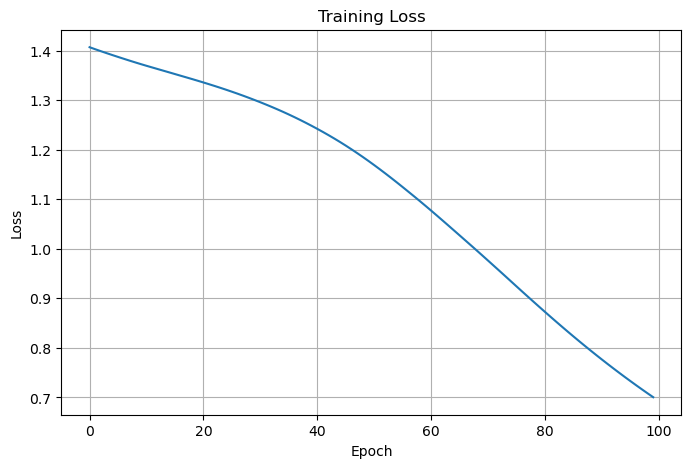

W0413 20:07:12.975000 2280 site-packages/torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features



Saved PyTorch weights to photo_assistant_model.pth


W0413 20:07:13.138000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::nms
W0413 20:07:13.139000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_align
W0413 20:07:13.139000 2280 site-packages/torch/onnx/_internal/exporter/_registration.py:110] torchvision is not installed. Skipping torchvision::roi_pool


[torch.onnx] Obtain model graph for `PhotoAssistantNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `PhotoAssistantNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/opt/anaconda3/lib/python3.13/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
The model version conversion is not supported by the onnxscript version converter and fallback is enabled. The model will be converted using the onnx C API (target version: 11).
Failed to convert the model to the target version 11 using the ONNX C API. The model was not modified
Traceback (most recent call last):
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_converter/__init__.py", line 120, in call
    converted_proto = _c_api_utils.call_onnx_api(
        func=_partial_convert_version, model=model
    )
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
  File "/Users/haileleul/.local/lib/python3.13/site-packages/onnxscript/version_convert

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Exported ONNX model to photo_assistant_model.onnx
Saved scaler/labels to photo_assistant_metadata.json


In [3]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import torch
import torch.nn as nn

# ----------------------------
# 1. Load dataset
# ----------------------------
df = pd.read_csv("dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nClass counts:")
print(df["label"].value_counts())

X = df[["light", "ax", "ay", "az", "gx", "gy", "gz"]].copy()
y = df["label"].copy()

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("\nLabel mapping:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"{cls} -> {i}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# ----------------------------
# 2. Define model
# ----------------------------
class PhotoAssistantNet(nn.Module):
    def __init__(self, input_size=7, num_classes=4):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 32)
        self.fc2 = nn.Linear(32, 16)
        self.fc3 = nn.Linear(16, num_classes)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = PhotoAssistantNet(input_size=7, num_classes=len(label_encoder.classes_))

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# ----------------------------
# 3. Train
# ----------------------------
epochs = 100
loss_history = []

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train_t)
    loss = loss_fn(outputs, y_train_t)
    loss.backward()
    optimizer.step()
    loss_history.append(loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}")

# ----------------------------
# 4. Evaluate
# ----------------------------
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_t)
    predictions = torch.argmax(test_outputs, dim=1)

accuracy = accuracy_score(y_test_t.numpy(), predictions.numpy())
cm = confusion_matrix(y_test_t.numpy(), predictions.numpy())

print(f"\nTest Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(
    y_test_t.numpy(),
    predictions.numpy(),
    target_names=label_encoder.classes_,
    zero_division=0
))

plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# ----------------------------
# 5. Save PyTorch model
# ----------------------------
torch.save(model.state_dict(), "photo_assistant_model.pth")
print("\nSaved PyTorch weights to photo_assistant_model.pth")

# ----------------------------
# 6. Export ONNX
# ----------------------------
dummy_input = torch.randn(1, 7, dtype=torch.float32)
torch.onnx.export(
    model,
    dummy_input,
    "photo_assistant_model.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11
)
print("Exported ONNX model to photo_assistant_model.onnx")

# ----------------------------
# 7. Save scaler + labels
# ----------------------------
metadata = {
    "feature_order": ["light", "ax", "ay", "az", "gx", "gy", "gz"],
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist(),
    "labels": label_encoder.classes_.tolist()
}

with open("photo_assistant_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("Saved scaler/labels to photo_assistant_metadata.json")